# Clasificador de autor en chats de WhatsApp con PLN

Este proyecto entrena un modelo de procesamiento de lenguaje natural para distinguir qué persona escribió cada mensaje de una conversación exportada de WhatsApp.

La idea sigue lo trabajado en los notebooks anteriores: tokenizacion, limpieza de texto, representacion con TF-IDF y clasificacion supervisada. Aqué lo aplicamos a un dataset real creado automaticamente desde uno o varios archivos `.txt` exportados desde WhatsApp.

**Objetivo:** dado el texto de un mensaje, predecir el autor más probable.




In [ ]:
import re
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from google.colab import files

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC

for recurso in ['punkt', 'punkt_tab', 'stopwords']:
    try:
        nltk.download(recurso, quiet=True)
    except Exception as error:
        print(f'No se pudo descargar {recurso}: {error}')

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')


## 2. Cargar uno o varios chats exportados

En WhatsApp puedes exportar una conversación como `.txt`. En Colab, sube aqué uno o varios archivos de chat. Cada archivo se convertirá en parte del dataset.


In [ ]:
USAR_UPLOAD = True

uploaded = files.upload()

rutas_chat = list(uploaded.keys())

if not rutas_chat:
    raise ValueError('Sube al menos un archivo .txt exportado desde WhatsApp.')

rutas_chat


Saving Chat de WhatsApp con Limbert.txt to Chat de WhatsApp con Limbert.txt


['Chat de WhatsApp con Limbert.txt']

## 3. Convertir el `.txt` de WhatsApp en un DataFrame

El formato usado por WhatsApp suele ser parecido a:

`24/3/2023, 10:34 p. m. - Nombre: Mensaje`

La función de abajo separa fecha, hora, autor y mensaje. Tambien conserva mensajes largos que ocupan varias líneas.


In [ ]:
PATRON_INICIO_MENSAJE = re.compile(
    r"""
    ^\[?
    (?P<fecha>\d{1,2}[/-]\d{1,2}[/-]\d{2,4})
    ,?\s+
    (?P<hora>\d{1,2}:\d{2}(?::\d{2})?)
    (?:\s*(?P<ampm>[apAP]\.\s*m\.|[apAP]m|AM|PM|am|pm))?
    \]?\s*[-–—]\s+
    (?:(?P<autor>[^:]+):\s*(?P<mensaje>.*)|(?P<sistema>.*))
    $
    """,
    re.VERBOSE,
)


def leer_texto_con_codificacion(path):
    """Lee exports de WhatsApp probando codificaciones frecuentes."""
    path = Path(path)
    for encoding in ['utf-8-sig', 'utf-8', 'latin-1', 'cp1252']:
        try:
            return path.read_text(encoding=encoding), encoding
        except UnicodeDecodeError:
            pass
    return path.read_text(encoding='utf-8', errors='replace'), 'utf-8-replace'


def normalizar_linea(linea):
    for caracter in ['\u202f', '\xa0', '\u200e', '\u200f']:
        linea = linea.replace(caracter, ' ')
    return linea.strip('\ufeff').strip()


def parsear_chat_whatsapp(path):
    texto, encoding = leer_texto_con_codificacion(path)
    filas = []
    lineas_sistema = []
    actual = None

    for raw in texto.splitlines():
        linea = normalizar_linea(raw)
        match = PATRON_INICIO_MENSAJE.match(linea)

        if match:
            if match.group('autor'):
                actual = {
                    'archivo': Path(path).name,
                    'fecha': match.group('fecha'),
                    'hora': match.group('hora'),
                    'ampm': match.group('ampm') or '',
                    'autor': match.group('autor').strip(),
                    'mensaje': (match.group('mensaje') or '').strip(),
                }
                filas.append(actual)
            else:
                actual = None
                lineas_sistema.append(linea)
        elif actual is not None:
            actual['mensaje'] += '\n' + linea
        elif linea.strip():
            lineas_sistema.append(linea)

    columnas = ['archivo', 'fecha', 'hora', 'ampm', 'autor', 'mensaje']
    df_chat = pd.DataFrame(filas, columns=columnas)
    info = {
        'archivo': Path(path).name,
        'encoding': encoding,
        'mensajes_parseados': len(df_chat),
        'lineas_sistema_o_no_parseadas': len(lineas_sistema),
        'primeras_lineas_no_parseadas': lineas_sistema[:3],
    }
    return df_chat, info


In [ ]:
datasets = []
reportes = []

for ruta in rutas_chat:
    df_chat, info = parsear_chat_whatsapp(ruta)
    datasets.append(df_chat)
    reportes.append(info)

columnas = ['archivo', 'fecha', 'hora', 'ampm', 'autor', 'mensaje']
df = pd.concat(datasets, ignore_index=True) if datasets else pd.DataFrame(columns=columnas)

for columna in columnas:
    if columna not in df.columns:
        df[columna] = ''

df['mensaje'] = df['mensaje'].fillna('').astype(str).str.strip()
df['autor'] = df['autor'].fillna('').astype(str).str.strip()

print(f'Dataset completo: {df.shape[0]:,} mensajes y {df["autor"].nunique()} autores')
display(pd.DataFrame(reportes))

if df.empty:
    raise ValueError(
        'No se detectaron mensajes. Revisa que subiste el .txt exportado desde WhatsApp, '
        'no un archivo comprimido .zip, y mira la columna primeras_lineas_no_parseadas '
        'para ajustar el formato si fuera necesario.'
    )

display(df.head())


Dataset completo: 3,047 mensajes y 2 autores


,archivo,encoding,mensajes_parseados,lineas_sistema_o_no_parseadas,primeras_lineas_no_parseadas
0,Chat de WhatsApp con Limbert.txt,utf-8-sig,3047,3,"[18/1/2025, 10:37 p. m. - Los mensajes y las llamadas están cifrados de extremo a extremo. Solo las personas en este..."


,archivo,fecha,hora,ampm,autor,mensaje
0,Chat de WhatsApp con Limbert.txt,18/1/2025,10:37,p. m.,Limbert,Che Albertango
1,Chat de WhatsApp con Limbert.txt,18/1/2025,10:37,p. m.,Limbert,Ya andaba haciendo las inscripciones
2,Chat de WhatsApp con Limbert.txt,18/1/2025,10:37,p. m.,Limbert,Vos sabes como funca la libre y hay que mandar solicitud para redes I no?
3,Chat de WhatsApp con Limbert.txt,18/1/2025,10:40,p. m.,Esteban,Yes
4,Chat de WhatsApp con Limbert.txt,18/1/2025,10:40,p. m.,Esteban,Lo mismo para libre


## 4. Exploración rápida del dataset

Antes de entrenar, revisamos cuántos mensajes aporta cada autor. Si un autor tiene muy pocos mensajes, el modelo aprende peor.


,autor,mensajes
0,Limbert,1587
1,Esteban,1460


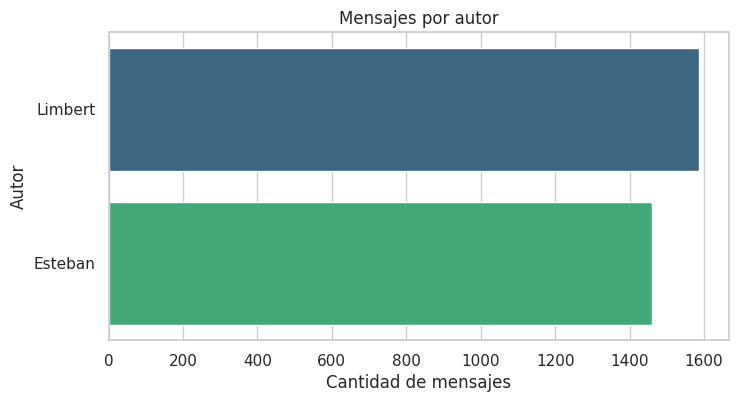

In [ ]:
conteo_autores = df['autor'].value_counts().rename_axis('autor').reset_index(name='mensajes')
display(conteo_autores)

plt.figure(figsize=(8, 4))
sns.barplot(data=conteo_autores, x='mensajes', y='autor', hue='autor', palette='viridis', legend=False)
plt.title('Mensajes por autor')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Autor')
plt.show()


## 5. Limpiar ruido y preparar el texto

Para clasificar autores conviene conservar parte del estilo de escritura: signos, muletillas, abreviaciones, emojis y palabras frecuentes pueden ser señales útiles. Por eso el modelo usa una limpieza ligera.

Aun así, se eliminan mensajes sin texto real, como multimedia omitida o mensajes eliminados.


In [ ]:
MIN_PALABRAS = 2
MIN_MENSAJES_POR_AUTOR = 20
MOSTRAR_EJEMPLOS = True

# Filtros para evitar que el modelo aprenda de mensajes que NO representan estilo real:
# código pegado, tareas copiadas, links, stickers, adjuntos, mensajes de sistema, spam de puntos, etc.
MAX_PALABRAS = 50
MAX_CARACTERES = 300
MAX_LINEAS = 5

patron_ruido = r"""
<multimedia omitido>|
multimedia omitido|
mensaje eliminado|
se elimin[oó] este mensaje|
imagen omitida|
video omitido|
audio omitido|
sticker omitido|
documento omitido|
archivo adjunto|
stk-\d+|
https?://|
www\.|
ubicaci[oó]n:|
bloqueaste a esta persona|
desbloqueaste a esta persona|
los mensajes y las llamadas están cifrados|
se edit[oó] este mensaje|
\.webp|
\.jpg|
\.jpeg|
\.png|
\.docx|
\.pdf|
\.java|
\.ipynb|
\.py|
\.js|
\.html|
\.css
"""

patron_codigo = r"""
(import\s+\w+|
from\s+\w+\s+import|
package\s+\w+|
public\s+class|
private\s+|
protected\s+|
static\s+void|
class\s+\w+|
def\s+\w+\s*\(|
function\s+\w+\s*\(|
console\.log|
print\s*\(|
System\.out|
Scanner\s+|
if\s*\(|
else\s*\{|
for\s*\(|
while\s*\(|
return\s+|
=>|
</?\w+|
SELECT\s+.*FROM|
INSERT\s+INTO|
CREATE\s+TABLE|
```|
\{|\}|
;|
==|
!=|
<=|
>=)
"""

# Textos académicos copiados o demasiado formales que no son estilo natural de chat.
patron_copy_paste_academico = r"""
an[aá]lisis de requisitos|
dise[nñ]o del sistema|
desarrollo del sistema|
pruebas del sistema|
despliegue y publicaci[oó]n|
mantenimiento y soporte|
feedback y mejora continua|
aplicaciones basadas en inteligencia artificial|
aprendizaje autom[aá]tico|
realidad aumentada|
realidad virtual|
desarrollo multiplataforma|
seguridad y privacidad|
ciudades inteligentes|
experiencia del usuario
"""

df_modelo = df.copy()
texto = df_modelo['mensaje'].fillna('').astype(str).str.strip()

# Métricas útiles para filtrar.
df_modelo['n_palabras'] = texto.str.split().str.len().fillna(0).astype(int)
df_modelo['n_caracteres'] = texto.str.len().fillna(0).astype(int)
df_modelo['n_lineas'] = texto.str.count('\n').fillna(0).astype(int) + 1

mascara_ruido = texto.str.lower().str.contains(patron_ruido, regex=True, na=False)
mascara_codigo = texto.str.contains(patron_codigo, case=False, regex=True, na=False)
mascara_academico = texto.str.contains(patron_copy_paste_academico, case=False, regex=True, na=False)

mascara_largo = (
    (df_modelo['n_palabras'] > MAX_PALABRAS) |
    (df_modelo['n_caracteres'] > MAX_CARACTERES) |
    (df_modelo['n_lineas'] > MAX_LINEAS)
)

# Mensajes que no aportan estilo: '.', '??', emojis solos, 'xd' demasiado corto, etc.
mascara_basura = (
    texto.str.fullmatch(r'[.\-_?¿!¡,;:\s😂🤣😭😔🫵❤🔥👍]*', na=False) |
    (texto.str.len() < 4)
)

# Repeticiones extremas de un mismo carácter: jajajaaaaaaa, ........, etc.
mascara_repetitivo = texto.str.contains(r'(.)\1{6,}', regex=True, na=False)

antes = len(df_modelo)
resumen_filtros = {
    'ruido_multimedia_sistema_links_adjuntos': int(mascara_ruido.sum()),
    'codigo_detectado': int(mascara_codigo.sum()),
    'copy_paste_academico': int(mascara_academico.sum()),
    'mensajes_largos': int(mascara_largo.sum()),
    'mensajes_basura_muy_cortos': int(mascara_basura.sum()),
    'mensajes_repetitivos': int(mascara_repetitivo.sum()),
}

df_modelo = df_modelo[
    (df_modelo['n_palabras'] >= MIN_PALABRAS) &
    ~mascara_ruido &
    ~mascara_codigo &
    ~mascara_academico &
    ~mascara_largo &
    ~mascara_basura &
    ~mascara_repetitivo
].copy()

despues_limpieza = len(df_modelo)

conteo_filtrado = df_modelo['autor'].value_counts()
autores_validos = conteo_filtrado[conteo_filtrado >= MIN_MENSAJES_POR_AUTOR].index
df_modelo = df_modelo[df_modelo['autor'].isin(autores_validos)].copy()

print('Resumen de filtros aplicados:')
display(pd.DataFrame([resumen_filtros]).T.rename(columns={0: 'mensajes_detectados'}))
print(f'Mensajes antes de limpiar: {antes:,}')
print(f'Mensajes después de limpiar ruido/código/largos: {despues_limpieza:,}')
print(f'Dataset final para entrenar: {df_modelo.shape[0]:,} mensajes')
print(f'Autores usados: {df_modelo["autor"].nunique()}')

display(df_modelo['autor'].value_counts().rename_axis('autor').reset_index(name='mensajes'))

if MOSTRAR_EJEMPLOS and len(df_modelo) > 0:
    display(
        df_modelo[
            ['archivo', 'fecha', 'hora', 'autor', 'mensaje', 'n_palabras', 'n_caracteres', 'n_lineas']
        ].sample(min(10, len(df_modelo)), random_state=42)
    )



Resumen de filtros aplicados:


/tmp/ipykernel_5626/581615101.py:106: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mascara_codigo = texto.str.contains(patron_codigo, case=False, regex=True, na=False)
/tmp/ipykernel_5626/581615101.py:122: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mascara_repetitivo = texto.str.contains(r'(.)\1{6,}', regex=True, na=False)


,mensajes_detectados
ruido_multimedia_sistema_links_adjuntos,2
codigo_detectado,12
copy_paste_academico,1
mensajes_largos,55
mensajes_basura_muy_cortos,441
mensajes_repetitivos,6


Mensajes antes de limpiar: 3,047
Mensajes después de limpiar ruido/código/largos: 2,259
Dataset final para entrenar: 2,259 mensajes
Autores usados: 2


,autor,mensajes
0,Limbert,1178
1,Esteban,1081


,archivo,fecha,hora,autor,mensaje,n_palabras,n_caracteres,n_lineas
2120,Chat de WhatsApp con Limbert.txt,17/11/2025,7:43,Limbert,Me sacaron el celu,4,18,1
548,Chat de WhatsApp con Limbert.txt,21/3/2025,9:20,Esteban,Vas a querer o no,5,17,1
728,Chat de WhatsApp con Limbert.txt,28/3/2025,4:29,Esteban,Andas capo,2,10,1
2061,Chat de WhatsApp con Limbert.txt,11/11/2025,11:54,Limbert,me lo puedes corregir como me quedo el primer ejercicio de lo que seria el Weather Image Recognition,18,100,1
72,Chat de WhatsApp con Limbert.txt,24/1/2025,8:51,Esteban,Mucha fiesta ese,3,16,1
1570,Chat de WhatsApp con Limbert.txt,30/9/2025,8:38,Esteban,Contexto mi estimado,3,20,1
1406,Chat de WhatsApp con Limbert.txt,15/9/2025,9:09,Esteban,"Buen día estimados estudiantes. Cómo es de su conocimiento, en el horario de nuestra clase se realizará la Asamblea ...",45,271,1
1452,Chat de WhatsApp con Limbert.txt,21/9/2025,10:36,Limbert,<Multimedia omitido>\nP11.mdl,3,28,2
148,Chat de WhatsApp con Limbert.txt,14/2/2025,7:28,Limbert,Olvídate Alberto,2,16,1
587,Chat de WhatsApp con Limbert.txt,21/3/2025,9:30,Esteban,Andas capo,2,10,1


In [ ]:
stopwords_es = set(stopwords.words('spanish'))

# Palabras basura que vienen de WhatsApp, adjuntos, links y archivos.
STOPWORDS_CUSTOM = {
    'archivo', 'adjunto', 'stk', 'webp', 'jpg', 'jpeg', 'png', 'gif', 'pdf', 'doc', 'docx',
    'ipynb', 'java', 'py', 'js', 'html', 'css', 'zip', 'rar', 'xlsx', 'pptx',
    'multimedia', 'omitido', 'omitida', 'mensaje', 'eliminó', 'elimino', 'editó', 'edito',
    'editado', 'cifrado', 'cifrados', 'llamadas', 'bloqueaste', 'desbloqueaste',
    'http', 'https', 'www', 'com', 'tiktok', 'youtube', 'youtu', 'maps', 'google', 'vt', 'vm',
    'wa', 'img', 'vid', 'aud', 'ptt', 'doc', 'pdf', 'wa', 'jpg', 'png'
}

# Muletillas demasiado dominantes del chat. Puedes comentar alguna si quieres conservarla.
PALABRAS_MUY_COMUNES = {
    'vos', 'che', 'ya', 'si', 'sí', 'ps', 'pues', 'nomas', 'nomás',
    'xd', 'jaja', 'jajaja', 'jajajaja', 'aja', 'ah', 'eh', 'que', 'qué', 'pero', 'para',
    'con', 'por', 'del', 'los', 'las', 'una', 'uno', 'ese', 'esa', 'eso', 'mas', 'más'
}

STOPWORDS_TOTALES = stopwords_es | STOPWORDS_CUSTOM | PALABRAS_MUY_COMUNES


def limpiar_tokens(texto):
    """Limpia texto para gráficas y modelo: quita adjuntos, links, código residual y muletillas dominantes."""
    texto = str(texto).lower()

    # Eliminar URLs y nombres típicos de archivos de WhatsApp.
    texto = re.sub(r'https?://\S+|www\.\S+', ' ', texto)
    texto = re.sub(r'\b(?:img|vid|stk|aud|ptt)-\d{8}-wa\d+\.[a-z0-9]+\b', ' ', texto)
    texto = re.sub(r'\b\S+\.(?:webp|jpg|jpeg|png|gif|pdf|docx?|ipynb|java|py|js|html|css|xlsx|pptx|zip|rar)\b', ' ', texto)

    # Quitar frases de sistema de WhatsApp que a veces sobreviven.
    texto = re.sub(r'archivo adjunto|multimedia omitido|se elimin[oó] este mensaje|se edit[oó] este mensaje', ' ', texto)

    # Dejar solo letras en español.
    texto = re.sub(r'[^a-záéíóúñü\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()

    tokens = texto.split()
    tokens = [
        token for token in tokens
        if len(token) >= 3
        and token not in STOPWORDS_TOTALES
        and not re.fullmatch(r'(.)\1+', token)  # elimina aaa, ooo, etc.
    ]
    return ' '.join(tokens)

def limpiar_para_modelo(texto):
    """Limpieza fuerte para que el modelo no aprenda de adjuntos, links, código residual ni palabras basura."""
    return limpiar_tokens(texto)

# Columna final limpia: úsala para gráficas y entrenamiento.
df_modelo['mensaje_limpio'] = df_modelo['mensaje'].apply(limpiar_tokens)

antes_tokens = len(df_modelo)
df_modelo = df_modelo[df_modelo['mensaje_limpio'].str.len() > 0].copy()
print(f'Mensajes eliminados porque quedaron vacíos después de limpiar tokens: {antes_tokens - len(df_modelo):,}')

display(df_modelo[['autor', 'mensaje', 'mensaje_limpio']].head())


Mensajes eliminados porque quedaron vacíos después de limpiar tokens: 335


,autor,mensaje,mensaje_limpio
0,Limbert,Che Albertango,albertango
1,Limbert,Ya andaba haciendo las inscripciones,andaba haciendo inscripciones
2,Limbert,Vos sabes como funca la libre y hay que mandar solicitud para redes I no?,sabes funca libre mandar solicitud redes
4,Esteban,Lo mismo para libre,mismo libre
5,Limbert,Y para la libre,libre


## 6. Gráficas de palabras más usadas por autor

Estas gráficas permiten comparar vocabulario y estilo de cada persona. Se quitan stopwords comunes en español para que resalten palabras más informativas.


In [ ]:
def tokenizar_para_graficas(texto):
    limpio = limpiar_tokens(texto)
    return limpio.split()


def tabla_palabras_por_autor(df_base, top=20):
    filas = []
    for autor, grupo in df_base.groupby('autor'):
        conteo = {}
        # Usa mensaje_limpio si existe; si no, limpia mensaje normal.
        columna = 'mensaje_limpio' if 'mensaje_limpio' in grupo.columns else 'mensaje'
        for mensaje in grupo[columna]:
            for token in tokenizar_para_graficas(mensaje):
                conteo[token] = conteo.get(token, 0) + 1

        total = sum(conteo.values()) or 1
        for palabra, frecuencia in sorted(conteo.items(), key=lambda item: item[1], reverse=True)[:top]:
            filas.append({
                'autor': autor,
                'palabra': palabra,
                'frecuencia': frecuencia,
                'porcentaje': frecuencia / total * 100,
            })
    return pd.DataFrame(filas)

palabras_autor = tabla_palabras_por_autor(df_modelo, top=20)
display(palabras_autor.head(40))


,autor,palabra,frecuencia,porcentaje
0,Esteban,andas,268,13.293651
1,Esteban,capo,242,12.003968
2,Esteban,saque,68,3.373016
3,Esteban,rojas,38,1.884921
4,Esteban,modo,37,1.835317
5,Esteban,nava,19,0.942460
6,Esteban,idea,18,0.892857
7,Esteban,vas,17,0.843254
8,Esteban,haz,16,0.793651
9,Esteban,navista,16,0.793651


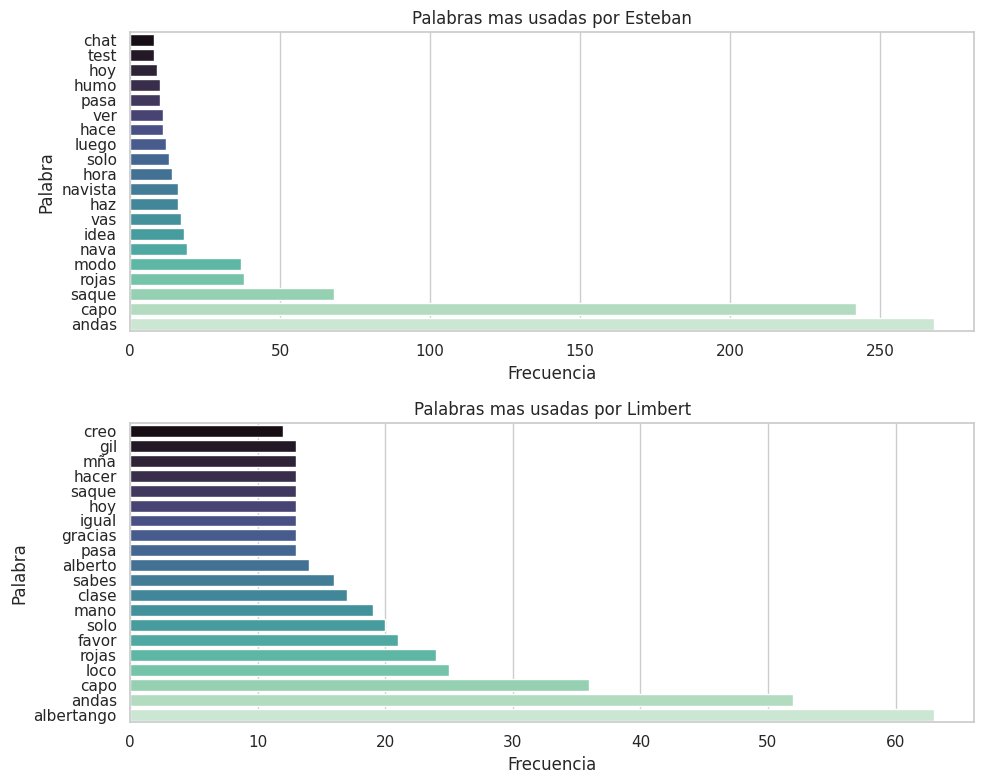

In [ ]:
if palabras_autor.empty:
    print('No hay suficientes palabras para graficar.')
else:
    autores = palabras_autor['autor'].unique()
    fig, axes = plt.subplots(
        nrows=len(autores),
        ncols=1,
        figsize=(10, max(4, 4 * len(autores))),
        squeeze=False,
    )

    for ax, autor in zip(axes.flat, autores):
        datos = palabras_autor[palabras_autor['autor'] == autor].sort_values('frecuencia', ascending=True)
        sns.barplot(data=datos, x='frecuencia', y='palabra', hue='palabra', ax=ax, palette='mako', legend=False)
        ax.set_title(f'Palabras mas usadas por {autor}')
        ax.set_xlabel('Frecuencia')
        ax.set_ylabel('Palabra')

    plt.tight_layout()
    plt.show()


In [ ]:
# Comparación directa entre autores: palabras que aparecen mucho más en uno que en el otro.
if df_modelo['autor'].nunique() == 2:
    autores = list(df_modelo['autor'].value_counts().index)
    conteos = {}

    for autor in autores:
        conteos[autor] = {}
        mensajes_autor = df_modelo.loc[df_modelo['autor'] == autor, 'mensaje_limpio']
        for mensaje in mensajes_autor:
            for token in tokenizar_para_graficas(mensaje):
                conteos[autor][token] = conteos[autor].get(token, 0) + 1

    vocabulario = sorted(set(conteos[autores[0]]) | set(conteos[autores[1]]))
    total_0 = sum(conteos[autores[0]].values()) or 1
    total_1 = sum(conteos[autores[1]].values()) or 1

    comparacion = []
    for palabra in vocabulario:
        f0 = conteos[autores[0]].get(palabra, 0)
        f1 = conteos[autores[1]].get(palabra, 0)
        if f0 + f1 >= 5:
            p0 = f0 / total_0
            p1 = f1 / total_1
            comparacion.append({
                'palabra': palabra,
                autores[0]: f0,
                autores[1]: f1,
                f'diferencia_hacia_{autores[0]}': p0 - p1,
                f'diferencia_hacia_{autores[1]}': p1 - p0,
            })

    comparacion = pd.DataFrame(comparacion)

    print(f'Palabras más características de {autores[0]}')
    display(comparacion.sort_values(f'diferencia_hacia_{autores[0]}', ascending=False).head(15))

    print(f'Palabras más características de {autores[1]}')
    display(comparacion.sort_values(f'diferencia_hacia_{autores[1]}', ascending=False).head(15))
else:
    print('La comparación característica está pensada para chats de 2 autores.')


Palabras más características de Limbert


,palabra,Limbert,Esteban,diferencia_hacia_Limbert,diferencia_hacia_Esteban
2,albertango,63,0,0.027344,-0.027344
70,loco,25,0,0.010851,-0.010851
47,favor,21,1,0.008619,-0.008619
76,mano,19,1,0.007750,-0.007750
123,sabes,16,1,0.006448,-0.006448
3,alberto,14,0,0.006076,-0.006076
20,clase,17,3,0.005890,-0.005890
51,gil,13,0,0.005642,-0.005642
84,mña,13,0,0.005642,-0.005642
52,gracias,13,1,0.005146,-0.005146


Palabras más características de Esteban


,palabra,Limbert,Esteban,diferencia_hacia_Limbert,diferencia_hacia_Esteban
6,andas,52,268,-0.110367,0.110367
16,capo,36,242,-0.104415,0.104415
125,saque,13,68,-0.028088,0.028088
82,modo,5,37,-0.016183,0.016183
65,idea,1,18,-0.008495,0.008495
120,rojas,24,38,-0.008433,0.008433
85,nava,3,19,-0.008123,0.008123
58,haz,1,16,-0.007502,0.007502
138,vas,5,17,-0.006262,0.006262
62,hora,4,14,-0.005208,0.005208


## 7. Separar entrenamiento y prueba

Usamos una división estratificada para que el conjunto de prueba mantenga proporciones similares de mensajes por autor.


In [ ]:
if df_modelo['autor'].nunique() < 2:
    raise ValueError('Se necesitan al menos 2 autores con suficientes mensajes para entrenar el modelo.')

# Ahora entrenamos con el texto limpio, no con el mensaje original.
X = df_modelo['mensaje_limpio']
y = df_modelo['autor']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f'Entrenamiento: {len(X_train):,} mensajes')
print(f'Prueba: {len(X_test):,} mensajes')


Entrenamiento: 1,539 mensajes
Prueba: 385 mensajes


## 8. Entrenar el modelo

El modelo usa dos tipos de señales:

- **N-gramas de palabras:** capturan expresiones frecuentes.
- **N-gramas de caracteres:** capturan estilo, abreviaciones, risas, puntuación y formas de escribir.

El clasificador será `LinearSVC`, como en el notebook de clasificación con TF-IDF.


In [ ]:
modelo = Pipeline([
    ('features', FeatureUnion([
        ('palabras', TfidfVectorizer(
            preprocessor=limpiar_para_modelo,
            analyzer='word',
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
        )),
        ('caracteres', TfidfVectorizer(
            preprocessor=limpiar_para_modelo,
            analyzer='char_wb',
            ngram_range=(3, 7),
            min_df=2,
            sublinear_tf=True,
        )),
    ])),
    ('clasificador', LinearSVC(class_weight='balanced', random_state=42)),
])

baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)

modelo.fit(X_train, y_train)
print('Modelo entrenado.')


Modelo entrenado.


## 9. Evaluar resultados

Comparamos contra una línea base que siempre predice el autor más frecuente. La métrica principal será `balanced_accuracy`, útil cuando los autores no tienen exactamente la misma cantidad de mensajes.


Balanced accuracy baseline: 0.5
Balanced accuracy modelo: 0.7142

Reporte de clasificación:
              precision    recall  f1-score   support

     Esteban      0.717     0.702     0.709       191
     Limbert      0.712     0.727     0.719       194

    accuracy                          0.714       385
   macro avg      0.714     0.714     0.714       385
weighted avg      0.714     0.714     0.714       385



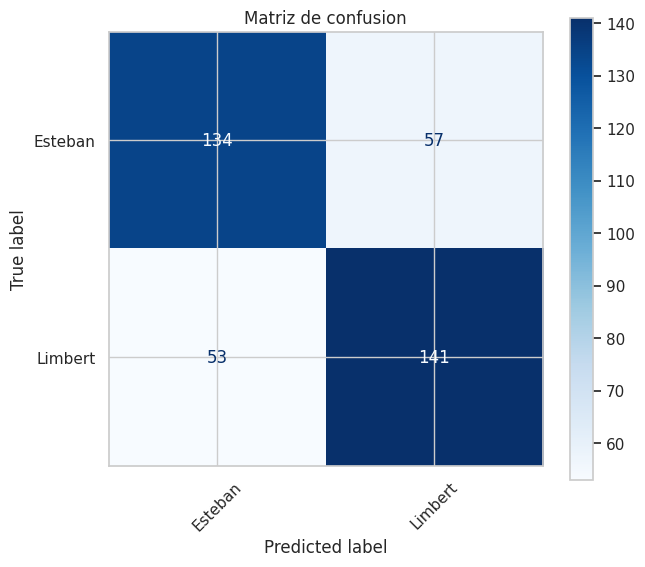

In [ ]:
y_pred_base = baseline.predict(X_test)
y_pred = modelo.predict(X_test)

print('Balanced accuracy baseline:', round(balanced_accuracy_score(y_test, y_pred_base), 4))
print('Balanced accuracy modelo:', round(balanced_accuracy_score(y_test, y_pred), 4))
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred, digits=3))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45,
    cmap='Blues',
    ax=ax,
)
plt.title('Matriz de confusion')
plt.show()


In [ ]:
HACER_VALIDACION_CRUZADA = True

if HACER_VALIDACION_CRUZADA:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        modelo,
        X,
        y,
        cv=cv,
        scoring='balanced_accuracy',
        n_jobs=-1,
    )
    print('Balanced accuracy por fold:', np.round(scores, 4))
    print('Promedio:', round(scores.mean(), 4))
    print('Desviación:', round(scores.std(), 4))


Balanced accuracy por fold: [0.6912 0.7535 0.678  0.7299 0.7239]
Promedio: 0.7153
Desviación: 0.0273


## 10. Ver qué señales usa el modelo

Esta sección ayuda a interpretar el modelo mostrando los rasgos de texto con mayor peso para cada autor. No significa que esas palabras sean exclusivas de una persona, solo que ayudaron al clasificador.


In [ ]:
def mostrar_rasgos_importantes(modelo, top=15):
    try:
        nombres = modelo.named_steps['features'].get_feature_names_out()
    except Exception as error:
        print(f'No se pudieron recuperar nombres de rasgos: {error}')
        return

    clasificador = modelo.named_steps['clasificador']
    clases = clasificador.classes_
    coefs = clasificador.coef_

    if len(clases) == 2:
        pesos = coefs[0]
        idx_pos = np.argsort(pesos)[-top:][::-1]
        idx_neg = np.argsort(pesos)[:top]

        print(f'Rasgos que empujan hacia: {clases[1]}')
        display(pd.DataFrame({'rasgo': nombres[idx_pos], 'peso': pesos[idx_pos]}))

        print(f'Rasgos que empujan hacia: {clases[0]}')
        display(pd.DataFrame({'rasgo': nombres[idx_neg], 'peso': pesos[idx_neg]}))
    else:
        for i, clase in enumerate(clases):
            pesos = coefs[i]
            idx = np.argsort(pesos)[-top:][::-1]
            print(f'Rasgos fuertes para: {clase}')
            display(pd.DataFrame({'rasgo': nombres[idx], 'peso': pesos[idx]}))

mostrar_rasgos_importantes(modelo, top=12)


Rasgos que empujan hacia: Limbert


,rasgo,peso
0,palabras__tas,1.219943
1,palabras__tipo,1.038019
2,palabras__sos,1.030153
3,palabras__dijo,0.997527
4,palabras__puro chat,0.964326
5,palabras__pes,0.957471
6,palabras__link,0.944013
7,palabras__primer,0.939153
8,palabras__albertango,0.934489
9,palabras__dices,0.891686


Rasgos que empujan hacia: Esteban


,rasgo,peso
0,palabras__andas rojas,-1.529763
1,palabras__igual rojas,-1.166528
2,palabras__hicimos,-1.089734
3,caracteres__ro,-1.080459
4,palabras__soda,-1.044862
5,palabras__visto,-0.970486
6,caracteres__rs,-0.925473
7,caracteres__do,-0.883152
8,palabras__hora,-0.872137
9,caracteres__ter,-0.871666


In [ ]:
def predecir_autor_con_puntajes(mensaje):
    mensaje_limpio = limpiar_tokens(mensaje)

    if len(mensaje_limpio.strip()) == 0:
        resultado = pd.DataFrame({
            'mensaje_original': [mensaje],
            'mensaje_limpio': [''],
            'prediccion': ['No clasificable']
        })
        return resultado, None

    prediccion = modelo.predict([mensaje_limpio])[0]

    # LinearSVC no tiene predict_proba, usamos decision_function como puntaje
    scores = modelo.decision_function([mensaje_limpio])

    clases = modelo.classes_

    if len(clases) == 2:
        scores = scores[0]
        puntajes = pd.DataFrame({
            'autor': clases,
            'puntaje': [-scores, scores]
        })
    else:
        puntajes = pd.DataFrame({
            'autor': clases,
            'puntaje': scores[0]
        })

    puntajes = puntajes.sort_values('puntaje', ascending=False)

    resultado = pd.DataFrame({
        'mensaje_original': [mensaje],
        'mensaje_limpio': [mensaje_limpio],
        'prediccion': [prediccion]
    })

    return resultado, puntajes

## 11. Insertar texto manualmente

Aqué puedes escribir un mensaje y el modelo predice el autor. La predicción se basa solo en patrones aprendidos del chat, así que funciona mejor con frases parecidas al estilo real de conversación.


In [ ]:
# Versión con caja de texto, útil en Google Colab.
try:
    import ipywidgets as widgets
    from IPython.display import clear_output, display

    caja_texto = widgets.Textarea(
        value='',
        placeholder='Escribe aqué un mensaje...',
        description='Mensaje:',
        layout=widgets.Layout(width='100%', height='100px'),
    )
    boton = widgets.Button(description='Predecir autor', button_style='primary')
    salida = widgets.Output()

    def al_hacer_click(_):
        with salida:
            clear_output()
            mensaje = caja_texto.value.strip()
            if not mensaje:
                print('Escribe un mensaje primero.')
                return

            resultado, puntajes = predecir_autor_con_puntajes(mensaje)
            display(resultado)
            if puntajes is not None:
                display(puntajes)

    boton.on_click(al_hacer_click)
    display(caja_texto, boton, salida)
except Exception as error:
    print('No se pudo cargar la caja interactiva. Usa la celda anterior con input().')
    print(error)


Textarea(value='', description='Mensaje:', layout=Layout(height='100px', width='100%'), placeholder='Escribe a…

Button(button_style='primary', description='Predecir autor', style=ButtonStyle())

Output()

## Conclusión

El modelo logró superar claramente la línea base, que representa una predicción simple del autor más frecuente. La métrica principal utilizada fue `balanced accuracy`, adecuada cuando la cantidad de mensajes por autor no es exactamente igual.

Los resultados muestran que el modelo sí aprende patrones de escritura relevantes para diferenciar autores, utilizando combinaciones de palabras y caracteres. Esto es especialmente útil en chats de WhatsApp porque cada persona suele escribir con abreviaciones, expresiones, signos, risas, muletillas y estructuras de texto particulares.

Como mejora futura, el modelo podría entrenarse con más conversaciones, probar modelos más avanzados y evaluar si mantiene el rendimiento en mensajes de fechas distintas.
